In [8]:
import numpy as np
from tabulate import tabulate                   # Para generar tablas
import matplotlib.pyplot as plt

from sklearn import datasets, tree                  # Módulo para levantar los datos
from sklearn.metrics import accuracy_score      # Medida de precisión
from sklearn.model_selection import KFold       # Modelo de partición

# Clasificadores:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

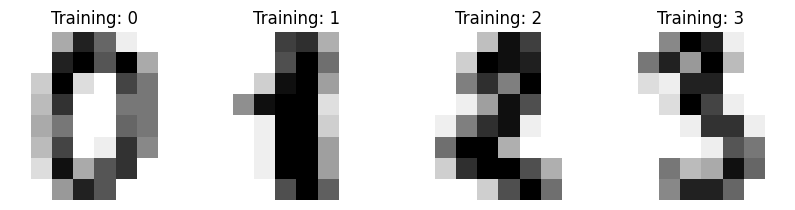

In [2]:
digits = datasets.load_digits()

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))

for ax, image, label in zip(axes, digits.images, digits.target): 
  ax.set_axis_off()
  ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
  ax.set_title("Training: %i" % label)

In [3]:
X_digits, y_digits = datasets.load_digits(return_X_y=True)

In [4]:
ACC_mean = []

# Naive Bayes
Se basa en el teorema de Bayes el cual establece que: 
$$
P(w|\mathbf{x}) = \frac{P(\mathbf{x}|w)P(w)}{P(\mathbf{x})}
$$ 
Es decir, cual es la probabilidad de que sea la clase $ w $, dado un patrón $\mathbf{x}$
Este modelo es algo ingenuo ya que viene de suponer que todas las caracteristicas son independientes entre si
De esta manera: 
$$ 
P(w, x_1, x_2, ..., x_n) = P(w)P(x_1|w)P(x_2|w)...P(x_n|w) = P(w) \prod_{i=1}^n P(x_i|w) 
$$ 
De esta forma nos queda
$$
P(w|x) = \frac{P(\mathbf{x}|w)P(w)}{P(x)} = \frac{P(w)\prod_{i=1}^nP(x_i|w)}{p(\mathbf{x})}
$$ 

Luego obtenemos la clase mas probable como: 
$$ 
\hat{w}(\mathbf{x}) = \text{arg max}_w \prod_{i=1}^n  (x_i |w)
$$ 

In [5]:
# Definimos el modelo
gnb = GaussianNB()

kf = KFold(n_splits=5, random_state=42, shuffle=True)

ACC = []

for fold, (train_index, test_index) in enumerate(kf.split(X_digits)): 
    X_train, y_train = X_digits[train_index], y_digits[train_index]
    X_test, y_test = X_digits[test_index], y_digits[test_index]
    # Entrenamiento del modelo
    gnb.fit(X_train, y_train)
    y_pred = gnb.predict(X_test)
    acc_fold = accuracy_score(y_test, y_pred)
    ACC.append(acc_fold)
        
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("Naive Bayes", np.mean(ACC)))
# Creamos una tabla
table_data = []
for i in range(len(ACC)):
    table_data.append({"Fold": i+1, "Accuracy": ACC[i]})

table = tabulate(table_data, headers="keys", tablefmt="simple_grid", stralign="center", numalign='center')
print(table)

% de aciertos medios: 0.8391674404209223
Varianza de la exactitud: 0.0003701695678499866
┌────────┬────────────┐
│  Fold  │  Accuracy  │
├────────┼────────────┤
│   1    │  0.847222  │
├────────┼────────────┤
│   2    │  0.847222  │
├────────┼────────────┤
│   3    │  0.802228  │
├────────┼────────────┤
│   4    │  0.857939  │
├────────┼────────────┤
│   5    │  0.841226  │
└────────┴────────────┘


# Analisis discriminante lineal
Sugieren una superficie de decision lineal (Lineas rectas en 2D, planos en 3D o hiperplanos en mas dimensiones) que separan las clases

In [6]:
# Definimos el modelo
clf = LinearDiscriminantAnalysis()

kf = KFold(n_splits=5, random_state=42, shuffle=True)

ACC = []

for fold, (train_index, test_index) in enumerate(kf.split(X_digits)): 
    X_train, y_train = X_digits[train_index], y_digits[train_index]
    X_test, y_test = X_digits[test_index], y_digits[test_index]
    # Entrenamiento del modelo
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc_fold = accuracy_score(y_test, y_pred)
    ACC.append(acc_fold)
        
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("ADL", np.mean(ACC)))
# Creamos una tabla
table_data = []
for i in range(len(ACC)):
    table_data.append({"Fold": i+1, "Accuracy": ACC[i]})

table = tabulate(table_data, headers="keys", tablefmt="simple_grid", stralign="center", numalign='center')
print(table)

% de aciertos medios: 0.9521340142370782
Varianza de la exactitud: 0.0002465860793586883
┌────────┬────────────┐
│  Fold  │  Accuracy  │
├────────┼────────────┤
│   1    │  0.944444  │
├────────┼────────────┤
│   2    │   0.975    │
├────────┼────────────┤
│   3    │  0.938719  │
├────────┼────────────┤
│   4    │  0.966574  │
├────────┼────────────┤
│   5    │  0.935933  │
└────────┴────────────┘


In [6]:
def generar_kfold(X_digits, y_digits, clf, n_folds=5):
  kf = KFold(n_splits=5, random_state=42, shuffle=True)
  ACC = []

  for fold, (train_index, test_index) in enumerate(kf.split(X_digits)): 
      X_train, y_train = X_digits[train_index], y_digits[train_index]
      X_test, y_test = X_digits[test_index], y_digits[test_index]
      # Entrenamiento del modelo
      clf.fit(X_train, y_train)
      y_pred = clf.predict(X_test)
      acc_fold = accuracy_score(y_test, y_pred)
      ACC.append(acc_fold)

  return ACC


# K-Vecinos mas cercanos
Para clasifica unnuevo punto, buscamos los $k$ ejemplos mas cercanos en el conjunto de entrenamiento, y predecimos la clase mas comun entre ellos. Para esto utilizamos la distancia euclidiana: 
$$
d(x, x_i) = \sqrt{(x_1-x_{i1})² + (x_2-x_{i2})²+...+(x_n-x_{in})^2}
$$

No entrena, solo guardamos el dataset y buscamos vecinos en tiempo de prediccion

In [ ]:
print("-------------- K = 1 --------------")
# Todos estos estan mal ya que se debe poner el modelo dentro de la funcion kfold
clf = KNeighborsClassifier(n_neighbors=1)
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("K-means (K=1)", np.mean(ACC)))

-------------- K = 1 --------------
% de aciertos medios: 0.9877607551841535
Varianza de la exactitud: 5.751617364319533e-05


In [9]:
print("-------------- K = 2 --------------")
clf = KNeighborsClassifier(n_neighbors=2)
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("K-means (K=2)", np.mean(ACC)))

-------------- K = 2 --------------
% de aciertos medios: 0.9844165892912411
Varianza de la exactitud: 7.322907503629791e-05


In [10]:
print("-------------- K = 5 --------------")
clf = KNeighborsClassifier(n_neighbors=5)
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("K-means (K=5)", np.mean(ACC)))

-------------- K = 5 --------------
% de aciertos medios: 0.9860832559579078
Varianza de la exactitud: 6.833199848151633e-05


In [11]:
print("-------------- K = 10 --------------")
clf = KNeighborsClassifier(n_neighbors=10)
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("K-means (K=10)", np.mean(ACC)))

-------------- K = 10 --------------
% de aciertos medios: 0.9821866295264625
Varianza de la exactitud: 6.404391992958174e-05


#  Arbol de decision

In [ ]:

clf = DecisionTreeClassifier(criterion="gini")
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("Arbol de decision", np.mean(ACC)))

% de aciertos medios: 0.8592076756422159
Varianza de la exactitud: 0.00029043386850976827


In [10]:
text_representation = tree.export_text(clf)
print(text_representation)
with open("decistion_tree.log", "w") as fout:
    fout.write(text_representation)



|--- feature_21 <= 0.50
|   |--- feature_42 <= 8.50
|   |   |--- feature_5 <= 1.50
|   |   |   |--- feature_27 <= 12.50
|   |   |   |   |--- feature_37 <= 4.50
|   |   |   |   |   |--- feature_34 <= 5.00
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |--- feature_34 >  5.00
|   |   |   |   |   |   |--- feature_25 <= 3.00
|   |   |   |   |   |   |   |--- class: 6
|   |   |   |   |   |   |--- feature_25 >  3.00
|   |   |   |   |   |   |   |--- class: 8
|   |   |   |   |--- feature_37 >  4.50
|   |   |   |   |   |--- feature_43 <= 12.00
|   |   |   |   |   |   |--- feature_12 <= 9.50
|   |   |   |   |   |   |   |--- feature_35 <= 8.50
|   |   |   |   |   |   |   |   |--- feature_60 <= 14.00
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |--- feature_60 >  14.00
|   |   |   |   |   |   |   |   |   |--- class: 5
|   |   |   |   |   |   |   |--- feature_35 >  8.50
|   |   |   |   |   |   |   |   |--- class: 4
|   |   |   |   |   |   |--- feature_

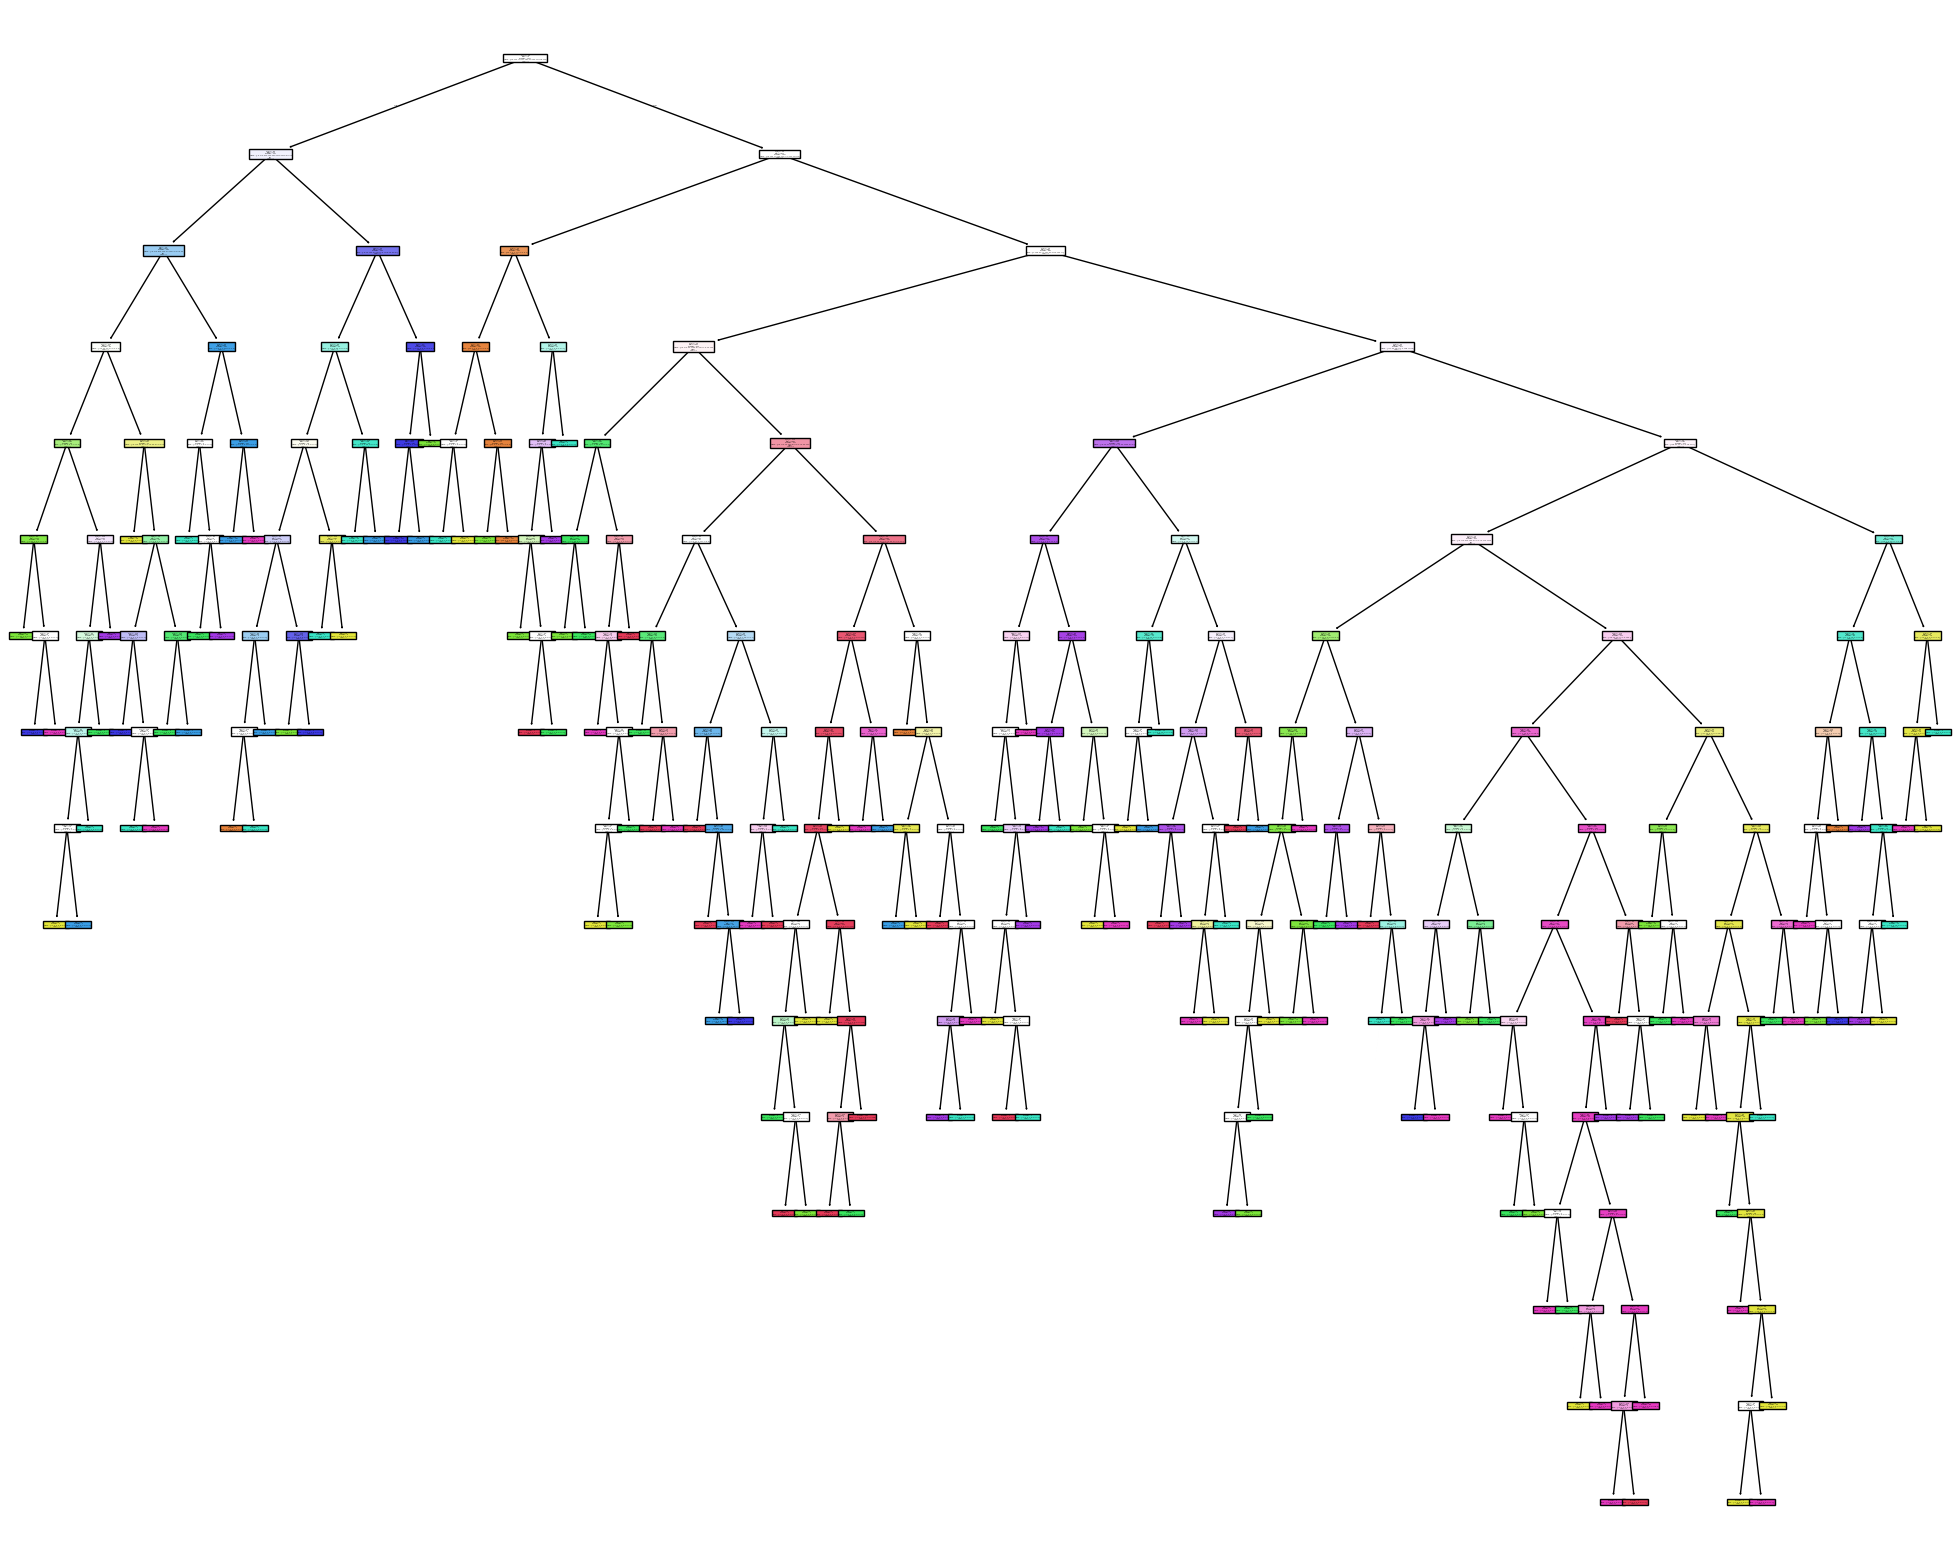

In [12]:

fig = plt.figure(figsize=(25, 20))
_ = tree.plot_tree(clf, 
                   filled=True,
                   class_names=[str(i) for i in clf.classes_])
fig.savefig("decistion_tree.png")
plt.show()

# Maquina de soporte vectorial

Una SVM busca un hiperplano que pare las clases de la manera mas optima.

¿Que pasa cuando los datos no son linealmente separables?

Para este clasificador, debido a que no es invariante en escala, utilizamos la funcion StandarScaler() para escalar los datos, estandarizandoos para que tengan media 0 y varianza 1

Podemos ver como actuan los diferentes kernels: 

![Gráfico de ejemplo](resources/svm_kernels.png)


### Linear

In [62]:
clf = make_pipeline(StandardScaler(), SVC(gamma="auto", kernel="linear"))
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("Maquina de soporte vectorial (Linear)", np.mean(ACC)))


% de aciertos medios: 0.9738362735995049
Varianza de la exactitud: 0.00010760389452955979


### Polynomial Kernel

In [63]:
clf = make_pipeline(StandardScaler(), SVC(gamma="auto", kernel="poly"))
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("Maquina de soporte vectorial (Poly)", np.mean(ACC)))


% de aciertos medios: 0.9493500464252553
Varianza de la exactitud: 0.00040237278411964054


### Radial basis Function

In [64]:
clf = make_pipeline(StandardScaler(), SVC(gamma="auto", kernel="rbf"))
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("Maquina de soporte vectorial (RBF)", np.mean(ACC)))


% de aciertos medios: 0.9794103992571961
Varianza de la exactitud: 2.667486065478492e-05


### Sigmoid Kernel

In [65]:
clf = make_pipeline(StandardScaler(), SVC(gamma="auto", kernel="sigmoid"))
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("Maquina de soporte vectorial (Sigmoid)", np.mean(ACC)))


% de aciertos medios: 0.9504766326214794
Varianza de la exactitud: 7.816897509339902e-05


In [66]:
# Creamos una tabla
ACC_mean = sorted(ACC_mean, key=lambda x: x[1], reverse=True)

table_data = []
for nombre, acc in ACC_mean:
    table_data.append({"Método": nombre, "Accuracy": acc})

table = tabulate(table_data, headers="keys", tablefmt="simple_grid", stralign="center", numalign='center')
print(table)

┌────────────────────────────────────────┬────────────┐
│                 Método                 │  Accuracy  │
├────────────────────────────────────────┼────────────┤
│             K-means (K=1)              │  0.987761  │
├────────────────────────────────────────┼────────────┤
│             K-means (K=5)              │  0.986083  │
├────────────────────────────────────────┼────────────┤
│             K-means (K=2)              │  0.984417  │
├────────────────────────────────────────┼────────────┤
│             K-means (K=10)             │  0.982187  │
├────────────────────────────────────────┼────────────┤
│   Maquina de soporte vectorial (RBF)   │  0.97941   │
├────────────────────────────────────────┼────────────┤
│ Maquina de soporte vectorial (Linear)  │  0.973836  │
├────────────────────────────────────────┼────────────┤
│                  ADL                   │  0.952134  │
├────────────────────────────────────────┼────────────┤
│ Maquina de soporte vectorial (Sigmoid) │  0.95